# 01 · Market EDA — where does a battery make money?

**Question.** A battery earns by buying cheap hours and selling expensive ones on the German–Luxembourg day-ahead market.
Before modelling anything, we check *how much* spread there is, *when* it happens and *what drives it*.

Data: hourly day-ahead prices, load, wind and solar (Energy-Charts / SMARD, CC BY 4.0), weather forecasts (Open-Meteo) and
TTF gas (Yahoo). If the APIs are unreachable the pipeline switches to the calibrated fundamental simulator — the mode is printed below.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "backend").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "backend"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from gridalpha.data.lake import get_lake
from gridalpha.data.ingest import ingest

plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "font.size": 10})
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#898781"
lake = get_lake()
if not lake.exists("market_hourly"):
    ingest()          # auto: public APIs, falls back to the calibrated simulator
meta = lake.read_json("data_meta")
print("data mode:", meta["mode"], "| rows:", meta["rows"], "| last price:", meta["last_price_ts"])

data mode: synthetic | rows: 32807 | last price: 2026-09-26T21:00:00+00:00


In [2]:
df = lake.read("market_hourly").copy()
loc = df.index.tz_convert("Europe/Berlin")
df["date"], df["hour"], df["year"], df["month"] = loc.date, loc.hour, loc.year, loc.month
px = df.dropna(subset=["price"])
daily = px.groupby("date")["price"].agg(["mean", "min", "max"])
daily["spread"] = daily["max"] - daily["min"]
summary = px.groupby("year").agg(mean=("price", "mean"), p5=("price", lambda s: s.quantile(.05)),
                                 p95=("price", lambda s: s.quantile(.95)), min=("price", "min"),
                                 neg_hours=("price", lambda s: int((s < 0).sum())))
summary["avg_daily_spread"] = daily.groupby(pd.to_datetime(daily.index).year)["spread"].mean()
summary.round(1)

,mean,p5,p95,min,neg_hours,avg_daily_spread
year,,,,,,
2023,122.2,4.6,272.7,-42.7,316,113.5
2024,109.3,-2.4,234.5,-154.9,515,106.5
2025,90.8,-6.4,189.0,-155.3,740,114.1
2026,87.7,-10.3,188.2,-165.6,779,122.8


**Reference (real market, 2025):** mean ≈ 89 €/MWh, ≈ 573 negative hours, average daily spread ≈ 130 €/MWh, record low −250 €/MWh
(Bloomberg/Montel, FfE). Negative hours keep rising with solar build-out — that is exactly the raw material of storage.

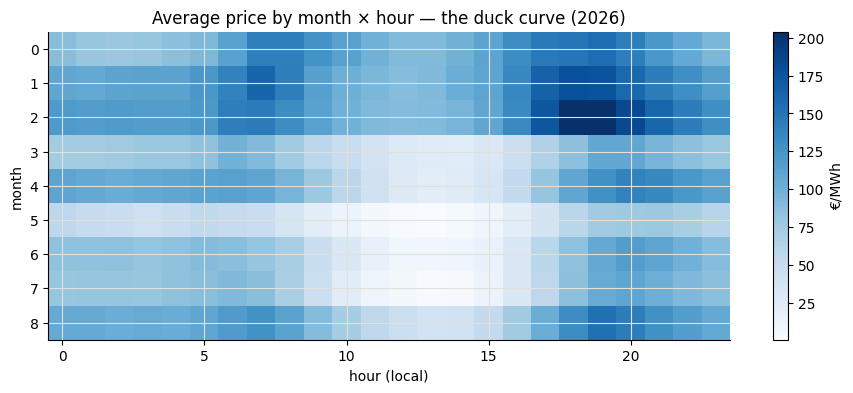

In [3]:
prof = px[px.year == px.year.max()].pivot_table(index="month", columns="hour", values="price", aggfunc="mean")
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(prof, aspect="auto", cmap="Blues")
ax.set(xlabel="hour (local)", ylabel="month", title=f"Average price by month × hour — the duck curve ({px.year.max()})")
fig.colorbar(im, label="€/MWh"); plt.show()

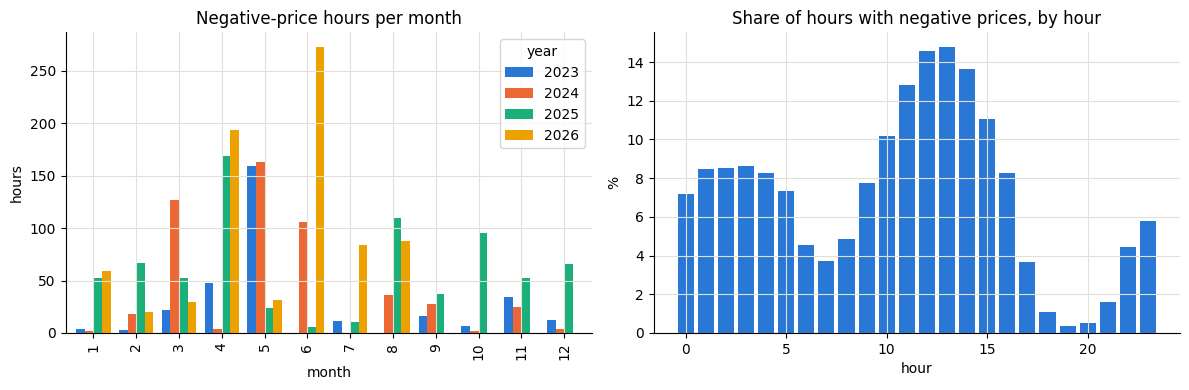

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
neg = px.assign(neg=px.price < 0).groupby(["year", "month"])["neg"].sum().unstack(0)
neg.plot(kind="bar", ax=axes[0], color=[BLUE, ORANGE, AQUA, YELLOW][: neg.shape[1]], width=0.8)
axes[0].set(title="Negative-price hours per month", xlabel="month", ylabel="hours")
by_hour = px.assign(neg=px.price < 0).groupby("hour")["neg"].mean() * 100
axes[1].bar(by_hour.index, by_hour.values, color=BLUE)
axes[1].set(title="Share of hours with negative prices, by hour", xlabel="hour", ylabel="%")
plt.tight_layout(); plt.show()

## The merit order in one picture
Prices are set by the most expensive plant needed. What matters is **residual load** = load − wind − solar: when renewables
cover the load, price collapses (even below zero); when they don't, gas plants set the price.

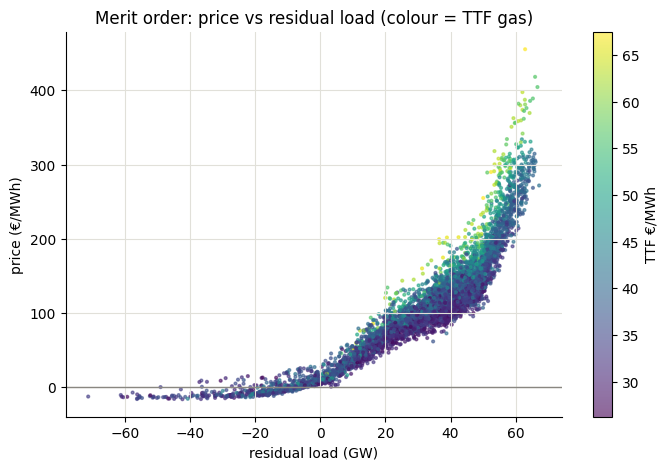

correlation price ~ residual load: 0.89


In [5]:
px = px.assign(residual=(px.load - px.solar - px.wind_onshore - px.wind_offshore) / 1000)
s = px.sample(min(8000, len(px)), random_state=0)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(s.residual, s.price, c=s.ttf, s=4, cmap="viridis", alpha=.6)
ax.axhline(0, color=GRAY, lw=1)
ax.set(xlabel="residual load (GW)", ylabel="price (€/MWh)", title="Merit order: price vs residual load (colour = TTF gas)")
fig.colorbar(sc, label="TTF €/MWh"); plt.show()
print("correlation price ~ residual load:", round(px[["price", "residual"]].corr().iloc[0, 1], 3))

## How much is perfect foresight worth?
Upper bound of day-ahead arbitrage for a 1 MW / 2 MWh battery (88 % round-trip, ≤ 1.5 cycles/day) solved as a MILP per day.
Every forecast-driven strategy is measured as a **capture ratio** against this ceiling.

perfect-foresight revenue, last 365 days: 76,189 €/MW  |  mean 209 €/day  |  best day 543 €  |  worst day 10 €


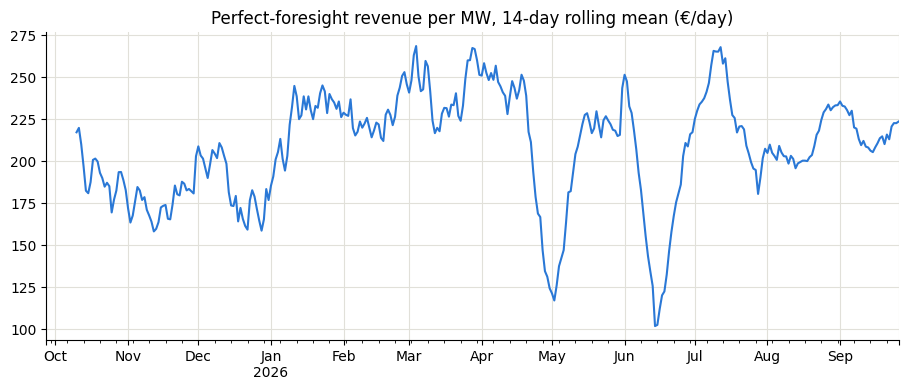

In [6]:
from gridalpha.trading.battery import BatterySpec, optimise
spec = BatterySpec(power_mw=1, energy_mwh=2, rte=0.88, max_cycles_per_day=1.5, degradation_eur_per_mwh=0,
                   soc_min_frac=0, soc_max_frac=1)
last365 = px[px.date >= (pd.Timestamp(px.date.max()) - pd.Timedelta(days=364)).date()]
rev = {d: optimise(spec, g.price.to_numpy()).expected_pnl for d, g in last365.groupby("date")}
rev = pd.Series(rev)
print(f"perfect-foresight revenue, last 365 days: {rev.sum():,.0f} €/MW  |  mean {rev.mean():,.0f} €/day  |  "
      f"best day {rev.max():,.0f} €  |  worst day {rev.min():,.0f} €")
rev.index = pd.to_datetime(rev.index)
rev.rolling(14).mean().plot(color=BLUE, title="Perfect-foresight revenue per MW, 14-day rolling mean (€/day)"); plt.show()

**Takeaways**
1. The value is concentrated in a few hours per day (solar trough → evening peak) and it is seasonal.
2. Residual load explains most of the price level (strong monotone relation) → it is the backbone feature of the models.
3. The ceiling is known; the business question becomes *how much of it can a forecast capture?* → notebook 03.